# Forecasting Boardings Using CAD and PRESTO Data

Applying time series forecasting to predict future CAD boardings using adjusted long-term historical PRESTO data as the primary training input.

In [1]:
import numpy as np
import pandas as pd
#import pandasql as ps
import math
import itertools

#matplotlib libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import seaborn as sns

#date libraries
from dateutil import parser
from datetime import datetime, timedelta, date
import holidays

#prophet library
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation

#pandas options
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#matplotlib setting defaults
sns.set(font="DeJavu Sans",
        rc={
 "axes.axisbelow": False,
 "axes.edgecolor": "lightgrey",
 "axes.facecolor": "None",
 "axes.grid": False,
 "axes.labelcolor": "dimgrey",
 "axes.spines.right": False,
 "axes.spines.top": False,
 "figure.facecolor": "white",
 "lines.solid_capstyle": "round",
 "patch.edgecolor": "w",
 "patch.force_edgecolor": True,
 "text.color": "dimgrey",
 "xtick.bottom": False,
 "xtick.color": "dimgrey",
 "xtick.direction": "out",
 "xtick.top": False,
 "ytick.color": "dimgrey",
 "ytick.direction": "out",
 "ytick.left": False,
 "ytick.right": False})


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def missing_data(input_data):
    '''
    This function returns dataframe with information about the percentage of nulls in each column and the column data type.

    input: pandas df
    output: pandas df

    '''

    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum()/input_data.isnull().count()*100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns:
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table))

def mape(actual, pred):
    '''
    Mean Absolute Percentage Error (MAPE) Function

    input: list/series for actual values and predicted values
    output: mape value
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [3]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BSD/PRESTO Boardings 2019-01-01 to 2025-04-16.csv")
df.columns = df.columns.str.replace(' ', '_').str.lower()


df = df.groupby(['serial_date'])['total_boardings'].sum().reset_index()

df['date'] = pd.to_datetime(df['serial_date'])

In [4]:
min(df['date']), max(df['date'])

(Timestamp('2018-11-01 00:00:00'), Timestamp('2025-04-16 00:00:00'))

In [5]:
df.head()

,serial_date,total_boardings,date
0,2018-11-01,54294,2018-11-01
1,2018-11-02,54441,2018-11-02
2,2018-11-03,20429,2018-11-03
3,2018-11-04,16532,2018-11-04
4,2018-11-05,53492,2018-11-05


In [6]:
import plotly.graph_objects as go


trips_summary = df


trips_summary['DayOfYear'] = trips_summary['date'].dt.dayofyear
trips_summary['Year'] = trips_summary['date'].dt.year


fig = go.Figure()


for year in trips_summary['Year'].unique():
    year_data = trips_summary[trips_summary['Year'] == year]
    fig.add_trace(go.Scatter(x=year_data['DayOfYear'],
                             y=year_data['total_boardings'],
                             mode='lines',
                             name=str(year)))


fig.update_layout(
    title='Total Daily Boardings by Year',
    xaxis_title='Day of Year',
    yaxis_title='Total Boardings',
    legend_title='Year',
    xaxis=dict(tickmode='linear', tick0=0, dtick=30),
    hovermode='x unified',
    template='plotly_dark',
    autosize=True
)

fig.show()


### Trend and Seasonality

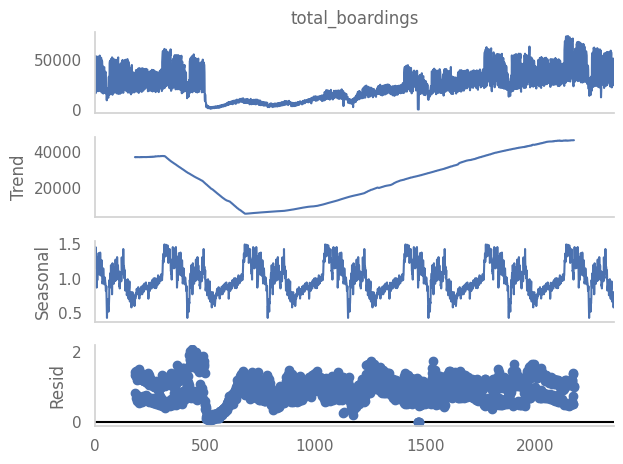

In [7]:
import statsmodels.api as sm
# plt.figure(figsize=(45,10))
plt.rcParams['font.family'] = 'DejaVu Sans'
decomposed = sm.tsa.seasonal_decompose(trips_summary['total_boardings'], model='multiplicative', period=365) # Assuming yearly seasonality
decomposed.plot();

### Working with Data from 2022 Onwards

In [8]:
df = df[df['date']>='2022-01-01']
df.set_index('date', inplace=True)

In [9]:
missing_data(df)

,Total,Percent,Types
serial_date,0,0.00,object
total_boardings,0,0.00,int64
DayOfYear,0,0.00,int32
Year,0,0.00,int32


### Data Cleaning


In [10]:

# old_len = len(df.columns)

# # Keep categories with avg daily boardings greater than 1000
total_boardings_df = df
# total_boardings_df = df.drop(columns=['serial_date','DayOfYear','Year'])[[col for col in df.columns if df[col].mean() > 1000]]

# print("Dropping " + str(old_len - len(total_boardings_df.columns)) + " columns due to insufficient data volume.")

In [11]:
#Get percentage of rows for each category that is at 0

(total_boardings_df == 0).astype(int).sum(axis=0)/len(total_boardings_df.sum(axis=0))

,0
serial_date,0.00
total_boardings,0.00
DayOfYear,0.00
Year,0.00


In [12]:
total_boardings_df=total_boardings_df[['serial_date','total_boardings']]
print(total_boardings_df.columns)

Index(['serial_date', 'total_boardings'], dtype='object')


In [13]:
#break out each into it's own dataframe for prediction since each will have different rows affected
import scipy.stats as stats
prediction_df_list = []

#Cleaning up dataframe using z-score to remove outliers which heavily bias the model
# Iterate through only numeric columns for z-score calculation
for column in total_boardings_df.select_dtypes(include=['number']).columns: # Exclude non-numeric columns
    df_clean = total_boardings_df[[column]].reset_index()

    z = np.abs(stats.zscore(df_clean[column]))
    outlier_index = np.where(z > 2.7)[0] #As 99.7% of the data points lie between 3 standard deviations
    print("Dropping "+str(len(outlier_index))+" rows for following category: "+column)
    df_clean.drop(index=outlier_index,inplace=True)
    df_clean.set_index('date', inplace=True)
    prediction_df_list.append(df_clean)

Dropping 0 rows for following category: total_boardings


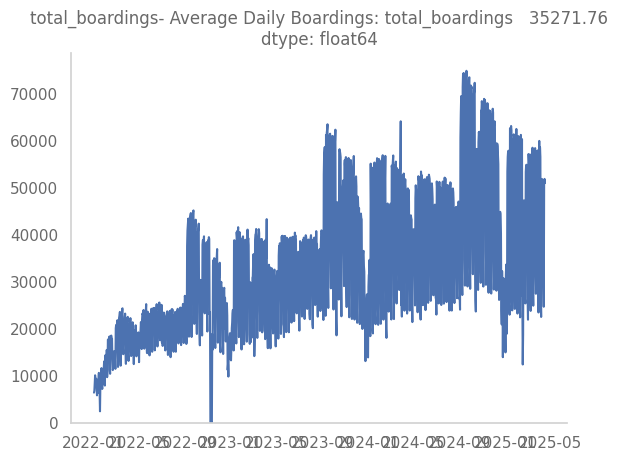

In [14]:
plt.rcParams['font.family'] = 'DejaVu Sans'

for i in range(len(prediction_df_list)):
    plt.plot(prediction_df_list[i])
    plt.title(prediction_df_list[i].columns[0]+'- Average Daily Boardings: '+str(prediction_df_list[i].mean()))
    plt.ylim(ymin=0)
    plt.show()

### For further hypertuning:

1. Impute or drop situations for the <b>Boardings</b>.

3. <b>Adjust the z-score outlier parameter</b> by checking out the Gaussian Distribution for different z-scores, check cut-offs and counts of rows being dropped, and see if there's an ideal situation for getting the best MAPE. (Idea is to loop through possible z-score possibilies, perhaps between 5 linear possibilities between 2.5 --> 3 and run the models with the best hypertuned parameters based on cross-validation below to see if MAPE's change with a change in z-score outlier drops.

In [15]:
#break it down by thirds for low, mid, high
avg_daily_boardings = total_boardings_df[['total_boardings']].apply(np.mean, axis=0).sort_values() # Only include the 'total_boardings' column
low, mid = np.percentile(total_boardings_df[['total_boardings']].apply(np.mean, axis=0).sort_values(),[33,66]) # Only include the 'total_boardings' column

In [16]:
# low_vol_columns = avg_daily_boardings[avg_daily_boardings<=low].index.tolist()
# mid_vol_columns = avg_daily_boardings[(avg_daily_boardings>low) & (avg_daily_boardings<mid)].index
# high_vol_columns = avg_daily_boardings[avg_daily_boardings>=mid].index

In [17]:
# #total_boardings_df[low_vol_columns].plot.line()
# plt.plot(total_boardings_df[low_vol_columns])
# plt.legend(low_vol_columns, loc='best') #, bbox_to_anchor=(1.1, 1.1))
# plt.show()

In [18]:
# plt.plot(total_boardings_df[mid_vol_columns])
# plt.legend(mid_vol_columns, loc='best', bbox_to_anchor=(1.1, 1.1))
# plt.xticks(rotation=30)
# plt.show()

In [19]:
# plt.plot(total_boardings_df[high_vol_columns])
# plt.legend(high_vol_columns, loc='best', bbox_to_anchor=(1.1, 1.1))
# plt.xticks(rotation=30)
# plt.show()

### Hyperparameter Tuning and Backtesting

Ranges give on Prophet's documentation

1. changepoint_prior_scale [0.001, 0.5]
2. seasonality_prior_scale [0.01, 10]
3. holidays_prior_scale [0.01, 10]
4. seasonality_mode ['additive', 'multiplicative'].
5. changepoint_range [0.5, 0.95]


In [20]:
changepoint_prior_scale_range = np.linspace(0.001, 0.5, num=5).tolist()
print(changepoint_prior_scale_range)

[0.001, 0.12575, 0.2505, 0.37525, 0.5]


In [21]:
seasonality_prior_scale_range = np.linspace(0.01, 10, num=5).tolist()
holidays_prior_scale_range = np.linspace(0.01, 10, num=5).tolist()

# seasonality_mode_options = ['additive', 'multiplicative'] # REMOVE
# changepoint_range_range = list(np.linspace(0.5, 0.95, num=5)) # REMOVE

In [22]:
import time
start_time = time.time()

dicts = {}

for feature in total_boardings_df.columns:
    # Skip 'serial_date' column as it contains dates and should not be converted to numeric
    if feature == 'serial_date':
        continue
    category_df = total_boardings_df[[feature]].copy().reset_index() # Only select the current feature column
    category_df.columns = ["ds", "y"]

    category_df[["y"]] = category_df[["y"]].apply(pd.to_numeric)
    category_df["ds"] = pd.to_datetime(category_df["ds"])

    param_grid = {
        "changepoint_prior_scale": changepoint_prior_scale_range,
        "seasonality_prior_scale": seasonality_prior_scale_range}
        #'holidays_prior_scale': holidays_prior_scale_range} # REMOVE
        # 'seasonality_mode': seasonality_mode_options, # REMOVE
        # 'changepoint_range': changepoint_range_range} # REMOVE

    # Generate all combinations of parameters
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    mapes = []

    # Use cross validation to evaluate all parameters
    for params in all_params:
        m = Prophet(**params).fit(category_df)  # Fit model with given params
        df_cv = cross_validation(m, initial="365 days", period="30 days", horizon = "30 days") #took parallel out
        df_p = performance_metrics(df_cv, rolling_window=1)
        print(df_p)
        mapes.append(df_p["mape"].values[0])

    # Find the best parameters
    tuning_results = pd.DataFrame(all_params)
    tuning_results["mape"] = mapes

    print(feature)
    print(tuning_results.head())

    params_dict = dict(tuning_results.sort_values("mape").reset_index(drop=True).iloc[0])
    params_dict["column"] = feature

    dicts[feature] = params_dict

print("--- %s seconds ---" % (time.time() - start_time)) #about 5 minutes

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/c3dgrthl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/6cokfvgd.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49055', 'data', 'file=/tmp/tmpiejynslp/c3dgrthl.json', 'init=/tmp/tmpiejynslp/6cokfvgd.json', 'output', 'file=/tmp/tmpiejynslp/prophet_modelskxxw2na/prophet_model-20250430190946.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:09:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:09:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 27 forecasts with cutoffs between 2023-01-27 00:00:00 and 2025-03-17 00:00:00


  0%|          | 0/27 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/6yuz95pk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/t2a0hpcg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95391', 'data', 'file=/tmp/tmpiejynslp/6yuz95pk.json', 'init=/tmp/tmpiejynslp/t2a0hpcg.json', 'output', 'file=/tmp/tmpiejynslp/prophet_modell60ztqla/prophet_model-20250430190947.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:09:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:09:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
19:09:47 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/pvt1kj7b.json
DE

  horizon          mse     rmse     mae  mape  mdape  smape  coverage
0 30 days 103954817.94 10195.82 8001.62  0.27   0.14   0.22      0.58


INFO:prophet:Making 27 forecasts with cutoffs between 2023-01-27 00:00:00 and 2025-03-17 00:00:00


...

  horizon         mse    rmse     mae  mape  mdape  smape  coverage
0 30 days 75191019.88 8671.28 6663.26  0.21   0.12   0.18      0.64


19:15:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 27 forecasts with cutoffs between 2023-01-27 00:00:00 and 2025-03-17 00:00:00


  0%|          | 0/27 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/uj4wpdv1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/becd2469.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69912', 'data', 'file=/tmp/tmpiejynslp/uj4wpdv1.json', 'init=/tmp/tmpiejynslp/becd2469.json', 'output', 'file=/tmp/tmpiejynslp/prophet_modelkc2j7dcb/prophet_model-20250430191559.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:15:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:15:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/lc11bfah.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/x3o3uk55.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

  horizon         mse    rmse     mae  mape  mdape  smape  coverage
0 30 days 74923653.83 8655.85 6648.83  0.21   0.12   0.18      0.65
total_boardings
   changepoint_prior_scale  seasonality_prior_scale  mape
0                     0.00                     0.01  0.27
1                     0.00                     2.51  0.25
2                     0.00                     5.00  0.25
3                     0.00                     7.50  0.25
4                     0.00                    10.00  0.25
--- 382.39342308044434 seconds ---


In [23]:
dicts

{'total_boardings': {'changepoint_prior_scale': np.float64(0.2505),
  'seasonality_prior_scale': np.float64(5.005),
  'mape': np.float64(0.19997944161048928),
  'column': 'total_boardings'}}

### Holidays

In [24]:
#adding holiday data

holiday = pd.DataFrame([])

canada_holidays = holidays.CA()
canada_holidays = holidays.country_holidays('CA')


for date_, name in sorted(holidays.CA(years=[2022,2023,2024,2025]).items()):
    holiday = pd.concat([holiday, pd.DataFrame({'ds': date_, 'holiday': "CA-Holidays", 'lower_window': -2, 'upper_window': 1}, index=[0])], ignore_index=True)

holiday['ds'] = pd.to_datetime(holiday['ds'], format='%Y-%m-%d', errors='ignore')
holiday.head()

<ipython-input-24-51eeb4c2c7ce>:12: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



,ds,holiday,lower_window,upper_window
0,2022-01-01,CA-Holidays,-2,1
1,2022-01-03,CA-Holidays,-2,1
2,2022-04-15,CA-Holidays,-2,1
3,2022-07-01,CA-Holidays,-2,1
4,2022-09-05,CA-Holidays,-2,1


https://pypi.org/project/holidays/

### Backtesting with Latest Metrics

In [25]:
prediction_days = 30
forecast_start_date = max(total_boardings_df.index) - timedelta(prediction_days)

[Timeseries From Scratch article](https://towardsdatascience.com/time-series-from-scratch-decomposing-time-series-data-7b7ad0c30fe7#:~:text=a%20single%20season.-,Multiplicative%20trend%20and%20additive%20seasonality,of%20seasonal%20periods%20over%20time.&text=You%20can%20see%20how%20the%20trend%20is%20slightly%20curved.)

In [26]:
#PROPHET MODEL

forecasted_dfs = []

for feature in total_boardings_df.columns:
    # Skip 'serial_date' column as it contains dates and should not be converted to numeric
    if feature == 'serial_date':
        continue
    #formatting
    df_copy = total_boardings_df[feature].copy().reset_index()
    df_copy.columns = ['ds','y']
    df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric)

    df_copy['ds'] = pd.to_datetime(df_copy['ds'])

    df_copy_ = df_copy[df_copy['ds'] < forecast_start_date]

    #finding the right params_dict for this category
    params_dict = dicts[feature]

    #model
    m = Prophet(changepoint_prior_scale = dicts[feature]['changepoint_prior_scale'],
                seasonality_prior_scale = dicts[feature]['seasonality_prior_scale'],
                seasonality_mode = 'multiplicative',
                #changepoint_range= len(df_copy/365),
                holidays=holiday
                 )

    m.fit(df_copy_)

    future = m.make_future_dataframe(periods=prediction_days)
    fcst_prophet_train = m.predict(future)

    filter = fcst_prophet_train['ds']>=forecast_start_date
    predicted_df = fcst_prophet_train[filter][['ds','yhat']]
    predicted_df = predicted_df.merge(df_copy, on='ds', how='left') # Merge on 'ds' column

    print(feature,mape(predicted_df['y'],predicted_df['yhat']))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/6ugc5u6k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/yd1idg8d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=9470', 'data', 'file=/tmp/tmpiejynslp/6ugc5u6k.json', 'init=/tmp/tmpiejynslp/yd1idg8d.json', 'output', 'file=/tmp/tmpiejynslp/prophet_model14fiah9g/prophet_model-20250430191609.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:16:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:16:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


total_boardings 8.027677084137029


### Forecasting with Prophet

In [27]:
from prophet import Prophet
import pandas as pd

prediction_days = 365
feature = 'total_boardings'

# Prepare
df_copy = total_boardings_df[[feature]].copy().reset_index()
df_copy.columns = ['ds', 'y']
df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric, errors='coerce')
df_copy['ds'] = pd.to_datetime(df_copy['ds'])

print("➡️ First date in training data:", df_copy['ds'].min())
print("➡️ Last date in training data:", df_copy['ds'].max())

# Drop
df_copy_ = df_copy.dropna(subset=['y'])

# Load Prophet parameters
params_dict = dicts[feature]

# Initialize and train
m = Prophet(
    changepoint_prior_scale=params_dict['changepoint_prior_scale'],
    seasonality_prior_scale=params_dict['seasonality_prior_scale'],
    seasonality_mode='multiplicative',
    holidays=holiday
)
m.fit(df_copy_)

# Create future dataframe and predict
future = m.make_future_dataframe(periods=prediction_days)
print("➡️ Last date in future DataFrame:", future['ds'].max())

fcst_prophet = m.predict(future)

# Print how many rows are in the forecast part
print("➡️ Total rows in prediction result:", len(fcst_prophet))
print("➡️ Date range of predictions:", fcst_prophet['ds'].min(), "to", fcst_prophet['ds'].max())

# Show final tail rows
print("➡️ Last 5 prediction rows:")
print(fcst_prophet.tail())

# Get the last 30 days of forecast
future_forecast = fcst_prophet[-prediction_days:][['ds', 'yhat']]
print("✅ Number of rows in future_forecast:", len(future_forecast))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/zmcg9ne5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpiejynslp/nk35sirs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68355', 'data', 'file=/tmp/tmpiejynslp/zmcg9ne5.json', 'init=/tmp/tmpiejynslp/nk35sirs.json', 'output', 'file=/tmp/tmpiejynslp/prophet_model5lytf8l_/prophet_model-20250430191609.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:16:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


➡️ First date in training data: 2022-01-01 00:00:00
➡️ Last date in training data: 2025-04-16 00:00:00


19:16:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


➡️ Last date in future DataFrame: 2026-04-16 00:00:00
➡️ Total rows in prediction result: 1567
➡️ Date range of predictions: 2022-01-01 00:00:00 to 2026-04-16 00:00:00
➡️ Last 5 prediction rows:
             ds    trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
1562 2026-04-12 49498.12    15680.65    31210.85     43340.97     56016.86   
1563 2026-04-13 49502.43    39832.59    60104.68     43316.62     56049.28   
1564 2026-04-14 49506.73    43111.85    63158.27     43293.41     56081.70   
1565 2026-04-15 49511.03    43252.90    62081.32     43270.67     56114.11   
1566 2026-04-16 49515.34    42915.07    62722.48     43247.92     56146.53   

      CA-Holidays  CA-Holidays_lower  CA-Holidays_upper  holidays  \
1562         0.00               0.00               0.00      0.00   
1563         0.00               0.00               0.00      0.00   
1564         0.00               0.00               0.00      0.00   
1565         0.00               0.00               0.00     

In [28]:
total_boardings_df.columns

Index(['serial_date', 'total_boardings'], dtype='object')

In [29]:
fcst_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,CA-Holidays,CA-Holidays_lower,CA-Holidays_upper,holidays,holidays_lower,holidays_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2022-01-01,9062.60,-7586.70,5903.83,9062.60,9062.60,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-1.07,-1.07,-1.07,-0.32,-0.32,-0.32,-0.30,-0.30,-0.30,0.00,0.00,0.00,-676.23
1,2022-01-02,9176.73,-4503.20,8646.98,9176.73,9176.73,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.73,-0.73,-0.73,-0.44,-0.44,-0.44,-0.28,-0.28,-0.28,0.00,0.00,0.00,2451.00
2,2022-01-03,9290.87,-2960.03,10756.56,9290.87,9290.87,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.59,-0.59,-0.59,0.09,0.09,0.09,-0.26,-0.26,-0.26,0.00,0.00,0.00,3787.94
3,2022-01-04,9405.01,1232.51,14991.47,9405.01,9405.01,-0.06,-0.06,-0.06,-0.06,-0.06,-0.06,-0.13,-0.13,-0.13,0.17,0.17,0.17,-0.24,-0.24,-0.24,0.00,0.00,0.00,8216.17
4,2022-01-05,9519.15,2164.06,15757.00,9519.15,9519.15,0.00,0.00,0.00,0.00,0.00,0.00,-0.04,-0.04,-0.04,0.17,0.17,0.17,-0.21,-0.21,-0.21,0.00,0.00,0.00,9111.25


### Forecasting PRESTO Boardings

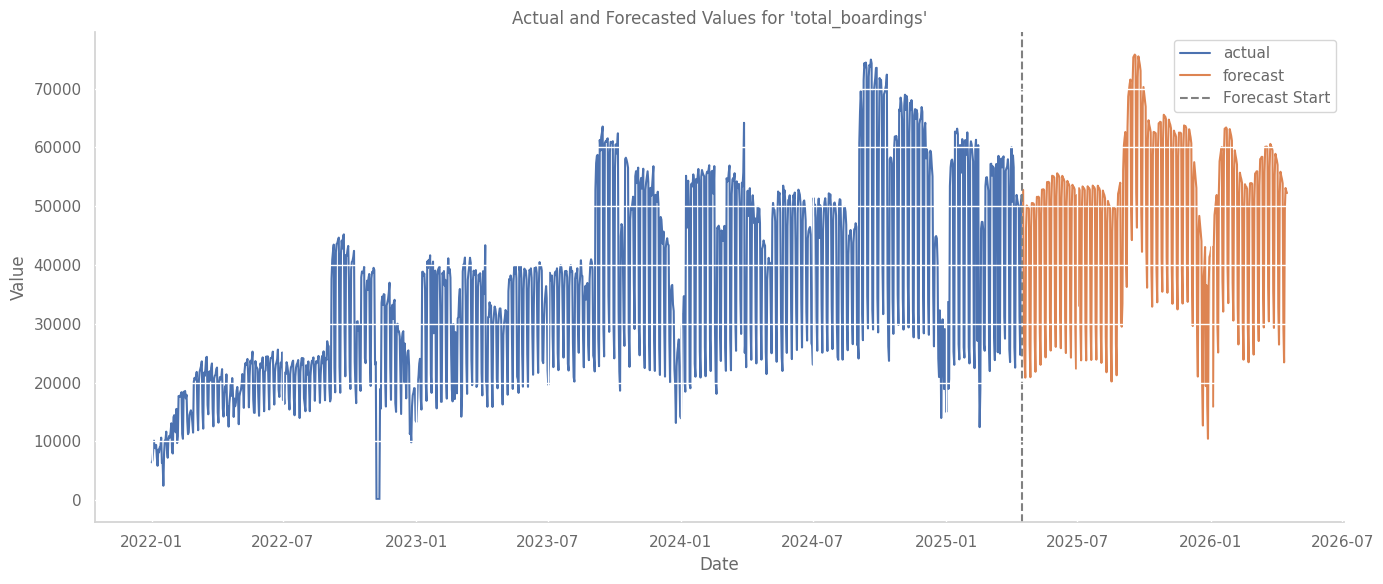

In [30]:
from logging import warning
import matplotlib.pyplot as plt

# Combine
df_plot = df_copy.copy()
df_plot['type'] = 'actual'

future_forecast_plot = future_forecast.copy()
future_forecast_plot.columns = ['ds', 'y']
future_forecast_plot['type'] = 'forecast'

combined_df = pd.concat([df_plot[['ds', 'y', 'type']], future_forecast_plot], ignore_index=True)

# Plot
plt.figure(figsize=(14, 6))
for label, df_grp in combined_df.groupby('type'):
    plt.plot(df_grp['ds'], df_grp['y'], label=label)

plt.title(f"Actual and Forecasted Values for '{feature}'")
plt.axvline(df_copy['ds'].max(), color='gray', linestyle='--', label='Forecast Start')
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



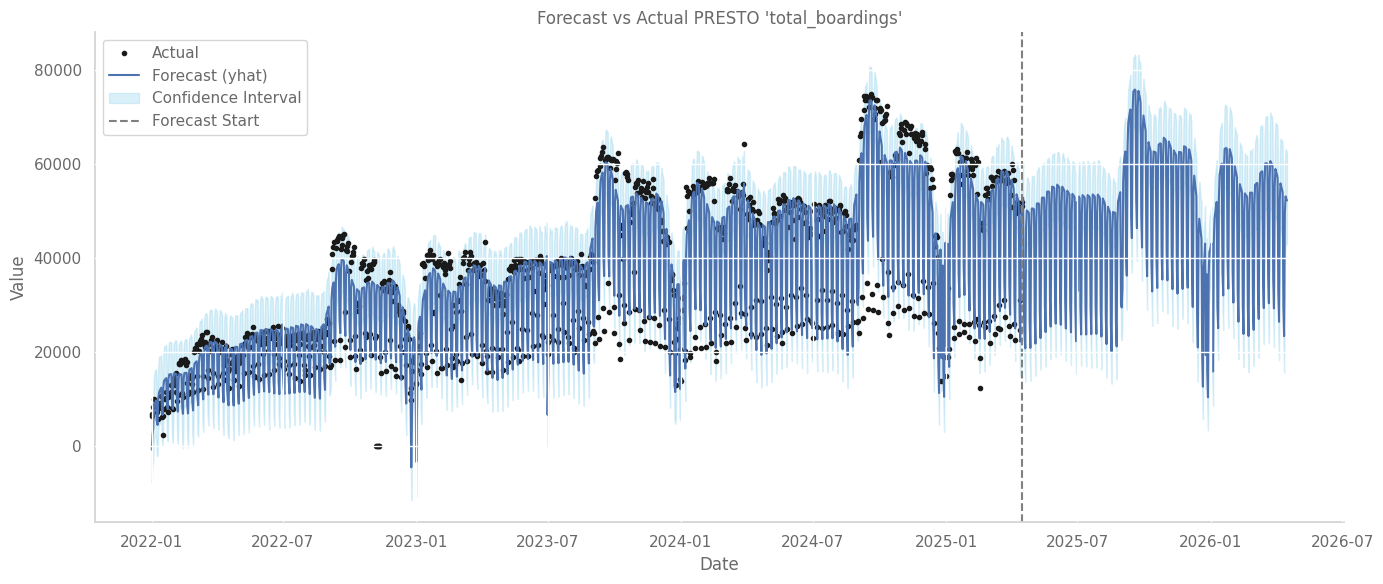

In [31]:
# Merge actuals with forecast
merged = fcst_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df_copy, on='ds', how='left')

plt.figure(figsize=(14, 6))

# Actual data (black dots)
plt.plot(merged['ds'], merged['y'], 'k.', label='Actual')

# Forecast (blue line)
plt.plot(merged['ds'], merged['yhat'], 'b-', label='Forecast (yhat)')

# Confidence interval (shaded area)
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'], color='skyblue', alpha=0.3, label='Confidence Interval')

# Formatting
plt.title(f"Forecast vs Actual PRESTO '{feature}'")
plt.axvline(df_copy['ds'].max(), color='gray', linestyle='--', label='Forecast Start')
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


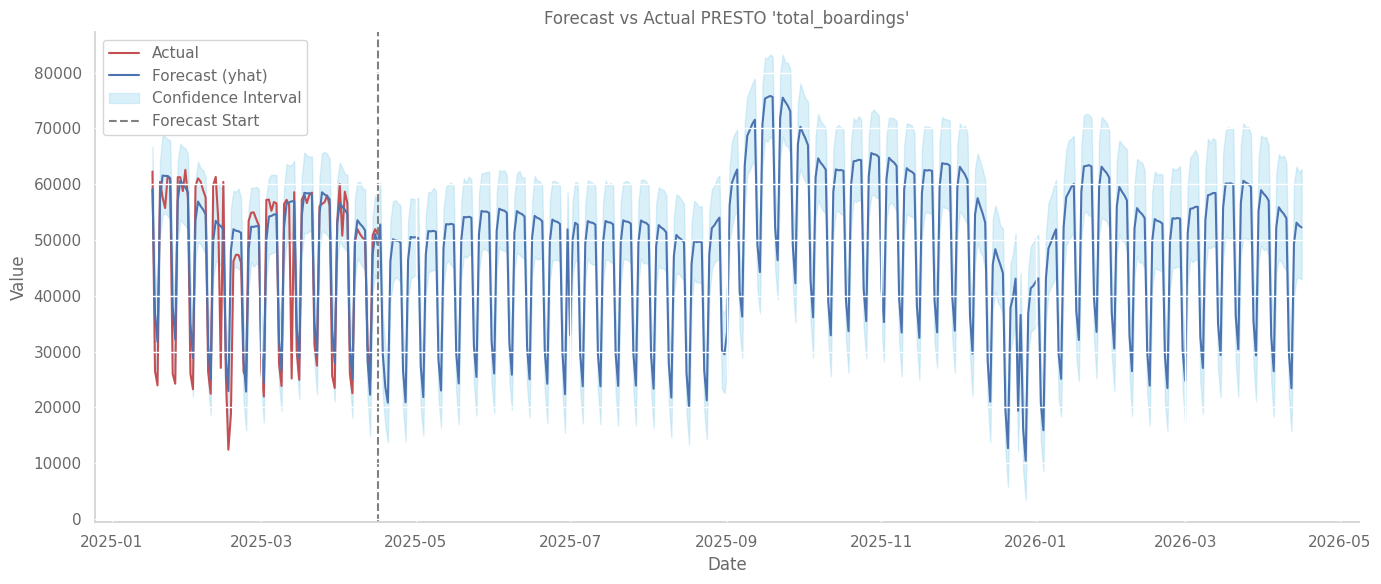

In [32]:
# Merge actuals with forecast
merged = fcst_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df_copy, on='ds', how='left')
merged = merged.loc[merged['ds']>total_boardings_df.index.max()-pd.Timedelta(days=90)] # showing last 90 days of actuals
plt.figure(figsize=(14, 6))

# Actual data (black dots)
plt.plot(merged['ds'], merged['y'], 'r-', label='Actual')

# Forecast (blue line)
plt.plot(merged['ds'], merged['yhat'], 'b-', label='Forecast (yhat)')

# Confidence interval (shaded area)
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'], color='skyblue', alpha=0.3, label='Confidence Interval')

# Formatting
plt.title(f"Forecast vs Actual PRESTO '{feature}'")
plt.axvline(df_copy['ds'].max(), color='gray', linestyle='--', label='Forecast Start')
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [33]:
# #Interactive Merged Plot
# merged = fcst_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df_copy, on='ds', how='left')
# merged = merged.loc[merged['ds']>total_boardings_df.index.max()-pd.Timedelta(days=90)] # showing last 90 days of actuals

# import plotly.graph_objects as go

# fig = go.Figure()

# # Actual data
# fig.add_trace(go.Scatter(x=merged['ds'], y=merged['y'], mode='lines', name='Actual', line=dict(color='red')))

# # Forecast
# fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat'], mode='lines', name='Forecast (yhat)', line=dict(color='blue')))

# # Confidence interval
# fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat_upper'], mode='lines', line=dict(width=0), showlegend=False))
# fig.add_trace(go.Scatter(x=merged['ds'], y=merged['yhat_lower'], mode='lines', fill='tonexty', fillcolor='rgba(51,153,255,0.3)', line=dict(width=0), name='Confidence Interval', showlegend=True))


# # Add vertical line for forecast start
# fig.add_shape(
#     dict(
#         type="line",
#         x0=df_copy['ds'].max(),
#         y0=merged['y'].min(),
#         x1=df_copy['ds'].max(),
#         y1=merged['y'].max(),
#         line=dict(color="gray", dash="dash"),
#     )
# )


# fig.update_layout(
#     title=f"Forecast vs Actual for '{feature}'",
#     xaxis_title="Date",
#     yaxis_title="Value",
#     hovermode='x unified',
#     template='plotly_dark',
#     autosize=True
#     )

# fig.show()


In [34]:
cad = pd.read_csv("/content/drive/My Drive/Colab Notebooks/BSD/Trips 2025-01-01 to 2025-04-29.csv")
cad.columns = cad.columns.str.replace(' ', '_').str.lower()


cad = cad.groupby(['opd_date'])['psngr_in_sum'].sum().reset_index()

cad['date'] = pd.to_datetime(cad['opd_date'])

In [35]:
import plotly.graph_objects as go

# Merge actuals with forecast
merged_fcst = fcst_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df_copy, on='ds', how='left')
merged_fcst = merged_fcst.loc[merged_fcst['ds'] > total_boardings_df.index.max() - pd.Timedelta(days=60)]

fig = go.Figure()

# Actual data
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['y'], mode='lines', name='Actual', line=dict(color='red')))

# Forecast
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat'], mode='lines', name='Forecast (yhat)', line=dict(color='blue')))

# Confidence interval
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat_upper'], mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat_lower'], mode='lines', fill='tonexty', fillcolor='rgba(51,153,255,0.3)', line=dict(width=0), name='Confidence Interval', showlegend=True))

# CAD data
fig.add_trace(go.Scatter(x=cad['date'], y=cad['psngr_in_sum'], mode='lines+markers', name='CAD', line=dict(color='green')))  # Overlay CAD data


# Add vertical line for forecast start
fig.add_shape(
    dict(
        type="line",
        x0=df_copy['ds'].max(),
        y0=merged_fcst['y'].min(),
        x1=df_copy['ds'].max(),
        y1=merged_fcst['y'].max(),
        line=dict(color="gray", dash="dash"),
    )
)


fig.update_layout(
    title=f"CAD Boardings vs PRESTO Forecast '{feature}'",
    xaxis_title="Date",
    yaxis_title="Value",
    hovermode='x unified',
    template='plotly_dark',
    autosize=True
    )

fig.show()


CAD boardings are a certain percentage higher than PRESTO boardings. PRESTO Boardings will be adjusted based on this ratio.

### Adjusting PRESTO Boardings

In [36]:

cad_and_presto = pd.merge(cad, fcst_prophet, left_on='date', right_on='ds', how='inner')

# Calculate the percentage difference
cad_and_presto['percentage_diff'] = ((cad_and_presto['psngr_in_sum'] - cad_and_presto['yhat']) / cad_and_presto['yhat']) * 100

In [37]:
# Calculate weekday/weekend percentage differences
cad_and_presto['weekday'] = cad_and_presto['date'].dt.weekday
cad_and_presto['is_weekend'] = cad_and_presto['weekday'] >= 5

weekday_data = cad_and_presto[~cad_and_presto['is_weekend']]
weekend_data = cad_and_presto[cad_and_presto['is_weekend']]

weekday_percentage_diff = (weekday_data['psngr_in_sum'].sum() / weekday_data['yhat'].sum()) * 100
weekend_percentage_diff = (weekend_data['psngr_in_sum'].sum() / weekend_data['yhat'].sum()) * 100

print(f"Weekday percentage difference: {weekday_percentage_diff:.2f}%")
print(f"Weekend percentage difference: {weekend_percentage_diff:.2f}%")


Weekday percentage difference: 153.84%
Weekend percentage difference: 168.64%


In [38]:
fcst_prophet_adjusted = fcst_prophet.copy()

# Create a new column 'weekday'
fcst_prophet_adjusted['weekday'] = fcst_prophet_adjusted['ds'].dt.weekday

# Create a new column 'is_weekend'
fcst_prophet_adjusted['is_weekend'] = fcst_prophet_adjusted['weekday'] >= 5

# Adjust 'yhat' based on weekday/weekend
fcst_prophet_adjusted['yhat'] = np.where(
    fcst_prophet_adjusted['is_weekend'],
    fcst_prophet_adjusted['yhat'] * (weekend_percentage_diff / 100),
    fcst_prophet_adjusted['yhat'] * (weekday_percentage_diff / 100)
)

# Adjust 'yhat_upper' and 'yhat_lower' similarly
fcst_prophet_adjusted['yhat_upper'] = np.where(
    fcst_prophet_adjusted['is_weekend'],
    fcst_prophet_adjusted['yhat_upper'] * (weekend_percentage_diff / 100),
    fcst_prophet_adjusted['yhat_upper'] * (weekday_percentage_diff / 100)
)

fcst_prophet_adjusted['yhat_lower'] = np.where(
    fcst_prophet_adjusted['is_weekend'],
    fcst_prophet_adjusted['yhat_lower'] * (weekend_percentage_diff / 100),
    fcst_prophet_adjusted['yhat_lower'] * (weekday_percentage_diff / 100)
)


In [39]:
import plotly.graph_objects as go


merged_fcst = fcst_prophet_adjusted[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(df_copy, on='ds', how='left')
merged_fcst = merged_fcst.loc[(merged_fcst['ds'] > total_boardings_df.index.max() - pd.Timedelta(days=60))]
# merged_fcst = merged_fcst.loc[merged_fcst['ds'] < cad['date'].max() + pd.Timedelta(days=30)]

fig = go.Figure()

# Actual data
# fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['y'], mode='lines', name='PRESTO Actual', line=dict(color='red')))

# Forecast
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat'], mode='lines', name='CAD Adjusted Forecast (yhat)', line=dict(color='pink')))

# Confidence interval
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat_upper'], mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=merged_fcst['ds'], y=merged_fcst['yhat_lower'], mode='lines', fill='tonexty', fillcolor='rgba(51,153,255,0.3)', line=dict(width=0), name='Confidence Interval', showlegend=False))

# CAD data
fig.add_trace(go.Scatter(x=cad['date'], y=cad['psngr_in_sum'], mode='lines+markers', name='CAD Actual', line=dict(color='green')))  # Overlay CAD data


# Add vertical line for forecast start
fig.add_shape(
    dict(
        type="line",
        x0=df_copy['ds'].max(),
        y0=merged_fcst['y'].min(),
        x1=df_copy['ds'].max(),
        y1=merged_fcst['y'].max(),
        line=dict(color="gray", dash="dash"),
    )
)


fig.update_layout(
    title=f"Adjusted CAD Forecast vs Actual CAD '{feature}'",
    xaxis_title="Date",
    yaxis_title="Value",
    hovermode='x unified',
    template='plotly_dark',
    autosize=True
    )

fig.show()


In [40]:
# Add helper columns for grouping
fcst_prophet_adjusted['year'] = fcst_prophet_adjusted['ds'].dt.year
fcst_prophet_adjusted['month'] = fcst_prophet_adjusted['ds'].dt.month

# Group by day and weekend flag first, then take mean at monthly level
daily_sums = fcst_prophet_adjusted.groupby(['year', 'month', 'is_weekend', 'ds'])['yhat'].sum().reset_index()

daily_sums['is_weekend'].replace({True: 'Weekend', False: 'Weekday'}, inplace=True)

# Now take the mean of daily sums grouped by year, month, is_weekend
monthly_avg = daily_sums.groupby(['year', 'month', 'is_weekend'])['yhat'].mean()


display(monthly_avg.unstack('year'))

print("Forecasted Average Daily Boardings per Month and Year")

<ipython-input-40-76313b05b73c>:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





year                 2022     2023      2024      2025     2026
month is_weekend                                               
1     Weekday    18917.17 49398.28  72959.25  82375.50 86553.26
      Weekend    10245.23 27352.46  45625.99  49158.79 50717.48
2     Weekday    23944.92 51115.04  74714.16  80728.20 83777.02
      Weekend    13639.48 28932.42  42709.41  47045.73 47845.10
3     Weekday    31295.93 56088.03  78705.32  86025.60 88679.65
      Weekend    18878.28 33486.56  47001.44  50967.36 52524.11
4     Weekday    31385.08 51883.12  73415.64  77357.66 83618.40
      Weekend    17640.72 29048.90  39469.55  41922.79 47413.74
5     Weekday    34922.42 55938.68  76192.48  80565.46      NaN
      Weekend    19394.26 31629.98  42386.79  45583.78      NaN
6     Weekday    37622.26 59439.62  78283.79  82307.37      NaN
      Weekend    21458.10 34003.05  44826.89  46076.62      NaN
7     Weekday    37772.25 59799.74  75748.07  79219.09      NaN
      Weekend    21248.85 30565.76  43216.78  45044.02      NaN
8     Weekday    38933.14 60112.03  75553.86  77791.88      NaN
      Weekend    20760.67 31754.69  41248.88  43179.02      NaN
9     Weekday    54837.05 83410.07 102091.04 104755.88      NaN
      Weekend    38200.86 57699.15  71411.99  75930.16      NaN
10    Weekday    51763.71 79273.07  95055.71  98179.77      NaN
      Weekend    34235.07 51358.85  60999.49  63269.07      NaN
11    Weekday    52326.19 80024.35  92953.92  95967.34      NaN
      Weekend    33359.86 51062.06  60146.87  61760.44      NaN
12    Weekday    41264.00 63024.68  71081.79  74271.90      NaN
      Weekend    20652.57 33567.43  36296.58  36676.47      NaN

Forecasted Average Daily Boardings per Month and Year


In [46]:
# fcst_prophet.to_csv("/content/drive/My Drive/Colab Notebooks/BSD/fcst_prophet_daily_boardings.csv", index=False)


In [41]:
# import xgboost as xgb
# import pandas as pd
# import numpy as np
# from datetime import timedelta

# # Parameters
# prediction_days = 365
# feature = 'total_boardings'

# # Prepare data
# df_copy = total_boardings_df[[feature]].copy().reset_index()
# df_copy.columns = ['ds', 'y']
# df_copy['ds'] = pd.to_datetime(df_copy['ds'])
# df_copy = df_copy.dropna(subset=['y']).sort_values('ds')

# # Feature engineering: use lag features
# df_copy['y_lag_1'] = df_copy['y'].shift(1)
# df_copy['y_lag_7'] = df_copy['y'].shift(7)
# df_copy = df_copy.dropna()

# # Train-test split
# train = df_copy.copy()

# # Model input
# X_train = train[['y_lag_1', 'y_lag_7']]
# y_train = train['y']

# # Train model
# model = xgb.XGBRegressor(n_estimators=100)
# model.fit(X_train, y_train)

# # Forecast
# last_known = df_copy.iloc[-1].copy()
# future_dates = [last_known['ds'] + timedelta(days=i+1) for i in range(prediction_days)]

# future_forecast = []

# prev_1 = last_known['y']
# prev_7_vals = list(df_copy.tail(7)['y'])  # take last 7 days

# for i in range(prediction_days):
#     # Get lag features
#     lag_1 = prev_1
#     lag_7 = prev_7_vals[-7] if len(prev_7_vals) >= 7 else np.mean(prev_7_vals)

#     x_input = np.array([[lag_1, lag_7]])
#     y_pred = model.predict(x_input)[0]

#     # Append result
#     forecast_date = last_known['ds'] + timedelta(days=i+1)
#     future_forecast.append({'ds': forecast_date, 'yhat': y_pred})

#     # Update lags
#     prev_1 = y_pred
#     prev_7_vals.append(y_pred)

# # Convert to DataFrame
# future_df = pd.DataFrame(future_forecast)

# # Plot
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 6))
# plt.plot(df_copy['ds'], df_copy['y'], label='Actual')
# plt.plot(future_df['ds'], future_df['yhat'], label='XGBoost Forecast')
# plt.axvline(df_copy['ds'].max(), color='gray', linestyle='--', label='Forecast Start')
# plt.legend()
# plt.title(f"{feature}: Actual + XGBoost Forecast ({prediction_days} days)")
# plt.xlabel("Date")
# plt.ylabel("Boardings")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [42]:
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb

# # Prepare features and target
# X = df_copy[['y_lag_1', 'y_lag_7']]
# y = df_copy['y']

# # Time-series split
# tscv = TimeSeriesSplit(n_splits=5)

# # Define parameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [2, 3, 4],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.8, 1.0],
# }

# # Initialize model
# model = xgb.XGBRegressor(random_state=42)

# # Grid search with cross-validation
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=tscv,
#     scoring='neg_mean_absolute_error',
#     verbose=1,
#     n_jobs=-1
# )

# # Fit grid search
# grid_search.fit(X, y)

# # Best model
# best_model = grid_search.best_estimator_
# print("✅ Best parameters:", grid_search.best_params_)


In [43]:
# import xgboost as xgb
# import pandas as pd
# import numpy as np
# from datetime import timedelta
# import matplotlib.pyplot as plt

# # Parameters
# prediction_days = 365
# feature = 'total_boardings'

# # Prepare data
# df_copy = total_boardings_df[[feature]].copy().reset_index()
# df_copy.columns = ['ds', 'y']
# df_copy['ds'] = pd.to_datetime(df_copy['ds'])
# df_copy = df_copy.dropna(subset=['y']).sort_values('ds')

# # Feature engineering: lag features
# df_copy['y_lag_1'] = df_copy['y'].shift(1)
# df_copy['y_lag_7'] = df_copy['y'].shift(7)
# df_copy = df_copy.dropna()

# # Train data
# X_train = df_copy[['y_lag_1', 'y_lag_7']]
# y_train = df_copy['y']

# # Train best model (assumes best_model is already defined from GridSearchCV)
# best_model.fit(X_train, y_train)

# # Forecast
# last_known = df_copy.iloc[-1].copy()
# future_forecast = []
# future_dates = [last_known['ds'] + timedelta(days=i+1) for i in range(prediction_days)]

# prev_1 = last_known['y']
# prev_7_vals = list(df_copy.tail(7)['y'])  # initialize with last 7 actuals

# for i in range(prediction_days):
#     lag_1 = prev_1
#     lag_7 = prev_7_vals[-7] if len(prev_7_vals) >= 7 else np.mean(prev_7_vals)

#     x_input = np.array([[lag_1, lag_7]])
#     y_pred = best_model.predict(x_input)[0]

#     forecast_date = last_known['ds'] + timedelta(days=i+1)
#     future_forecast.append({'ds': forecast_date, 'yhat': y_pred})

#     prev_1 = y_pred
#     prev_7_vals.append(y_pred)

# # Convert to DataFrame
# future_df = pd.DataFrame(future_forecast)

# # Plot
# plt.figure(figsize=(14, 6))
# plt.plot(df_copy['ds'], df_copy['y'], label='Actual')
# plt.plot(future_df['ds'], future_df['yhat'], label='XGBoost Forecast')
# plt.axvline(df_copy['ds'].max(), color='gray', linestyle='--', label='Forecast Start')
# plt.legend()
# plt.title(f"{feature}: Actual + XGBoost Forecast ({prediction_days} days)")
# plt.xlabel("Date")
# plt.ylabel("Boardings")
# plt.grid(True)
# plt.tight_layout()
# plt.show()
